In [1]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn as sk

In [2]:
DATA_DIR = "mu3e_trigger_data"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_positions.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_positions.npy"

max_barrel_radius = 86.3
max_endcap_distance = 372.6

In [3]:
signal_data = np.load(SIGNAL_DATA_FILE)
background_data = np.load(BACKGROUND_DATA_FILE)

background_data[background_data[:, :, 0] != -1, 0] = (
    background_data[background_data[:, :, 0] != -1, 0] + max_barrel_radius
) / max_barrel_radius
background_data[background_data[:, :, 0] != -1, 1] = (
    background_data[background_data[:, :, 0] != -1, 1] + max_barrel_radius
) / max_barrel_radius
background_data[background_data[:, :, 0] != -1, 2] = (
    background_data[background_data[:, :, 0] != -1, 2] + max_endcap_distance / 2
) / max_endcap_distance

signal_data[signal_data[:, :, 0] != -1, 0] = (
    signal_data[signal_data[:, :, 0] != -1, 0] + max_barrel_radius
) / max_barrel_radius
signal_data[signal_data[:, :, 0] != -1, 1] = (
    signal_data[signal_data[:, :, 0] != -1, 1] + max_barrel_radius
) / max_barrel_radius
signal_data[signal_data[:, :, 0] != -1, 2] = (
    signal_data[signal_data[:, :, 0] != -1, 2] + max_endcap_distance / 2
) / max_endcap_distance

In [4]:
pca_dim = 64
PCA = sk.decomposition.PCA(n_components=pca_dim)

In [5]:
PCA.fit(background_data.reshape(-1, 3 * 256))

,n_components,64
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [6]:
background_pca = PCA.transform(background_data.reshape(-1, 3 * 256))

In [7]:
signal_pca = PCA.transform(signal_data.reshape(-1, 3 * 256))

In [17]:
from src.model.components import (MLP)
input_layer = keras.layers.Input(shape=(pca_dim,))
laten_dim = pca_dim // 4
num_layers = 4
encoder = MLP(laten_dim, activation="relu", name="input_embedding", num_layers = num_layers)(input_layer)
decoder = MLP(pca_dim, activation="linear", name="output_embedding", num_layers = num_layers)(encoder)

autoencoder_model = keras.Model(inputs=input_layer, outputs=decoder, name="autoencoder")

In [18]:
autoencoder_model.summary()
autoencoder_model.compile(
    optimizer=keras.optimizers.Adam(1e-2),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.MeanSquaredError()])

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_embedding (MLP)           │ (None, 16)             │        10,982 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_embedding (MLP)          │ (None, 64)             │        11,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,030 (43.09 KB)

 Trainable params: 11,030 (43.09 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = autoencoder_model.fit(
    background_pca,
    background_pca,
    epochs=1000,
    batch_size=256,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),]
)

Epoch 1/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7674 - mean_squared_error: 0.7674 - val_loss: 0.2411 - val_mean_squared_error: 0.2411
Epoch 2/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2336 - mean_squared_error: 0.2336 - val_loss: 0.2142 - val_mean_squared_error: 0.2142
Epoch 3/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2090 - mean_squared_error: 0.2090 - val_loss: 0.1985 - val_mean_squared_error: 0.1985
Epoch 4/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1962 - mean_squared_error: 0.1962 - val_loss: 0.1965 - val_mean_squared_error: 0.1965
Epoch 5/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1895 - mean_squared_error: 0.1895 - val_loss: 0.1841 - val_mean_squared_error: 0.1841
Epoch 6/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1819 - mean_squared_error: 0.1819 - val_loss: 0.1810 - val_mean_squared_error: 0.1810
Epoch 7/1000
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1788 - mean_squared_error: 0.1788 - 

In [20]:
signal_diff = signal_pca - autoencoder_model.predict(signal_pca)
signal_diff = np.linalg.norm(signal_diff, axis=1)
background_diff = background_pca - autoencoder_model.predict(background_pca)
background_diff = np.linalg.norm(background_diff, axis=1)

3121/3121 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 664us/step


Text(0.5, 0, 'Difference')

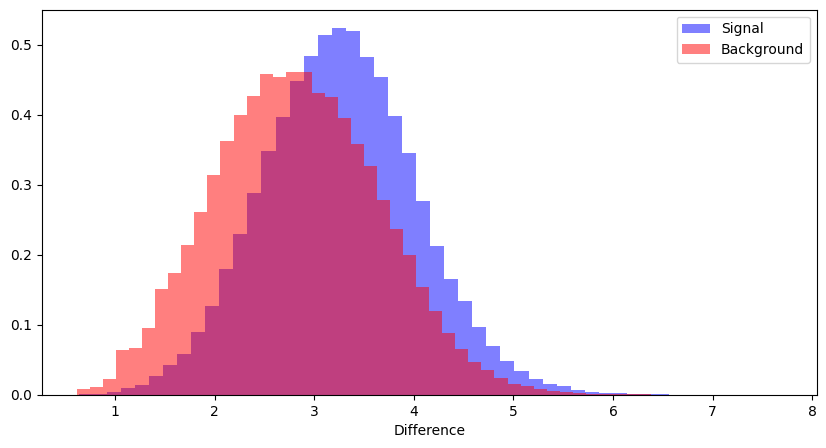

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(signal_diff, bins=50, alpha=0.5, label="Signal", color="blue", density=True)
plt.hist(background_diff, bins=50, alpha=0.5, label="Background", color="red", density=True)
plt.legend()
plt.xlabel("Difference")

In [22]:
number_hits_signal = ((signal_data != -1).any(axis = -1)).sum(axis=-1)
number_hits_background = ((background_data != -1).any(axis = -1)).sum(axis=-1)

Text(0.5, 0, 'Difference')

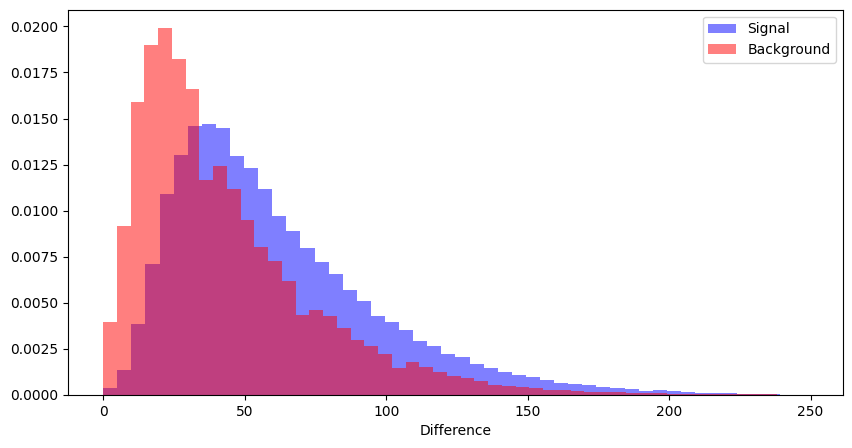

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(number_hits_signal, bins=50, alpha=0.5, label="Signal", color="blue", density=True)
plt.hist(number_hits_background, bins=50, alpha=0.5, label="Background", color="red", density=True)
plt.legend()
plt.xlabel("Difference")

In [24]:
from sklearn.metrics import roc_curve, auc
y_true = np.concatenate([np.ones(len(signal_diff)), np.zeros(len(background_diff))])
y_scores_autoencoder = np.concatenate([signal_diff, background_diff])
y_scores_hits = np.concatenate([number_hits_signal, number_hits_background])

fpr_autoencoder, tpr_autoencoder, _ = roc_curve(y_true, y_scores_autoencoder)
fpr_hits, tpr_hits, _ = roc_curve(y_true, y_scores_hits)

roc_auc_autoencoder = auc(fpr_autoencoder, tpr_autoencoder)
roc_auc_hits = auc(fpr_hits, tpr_hits)

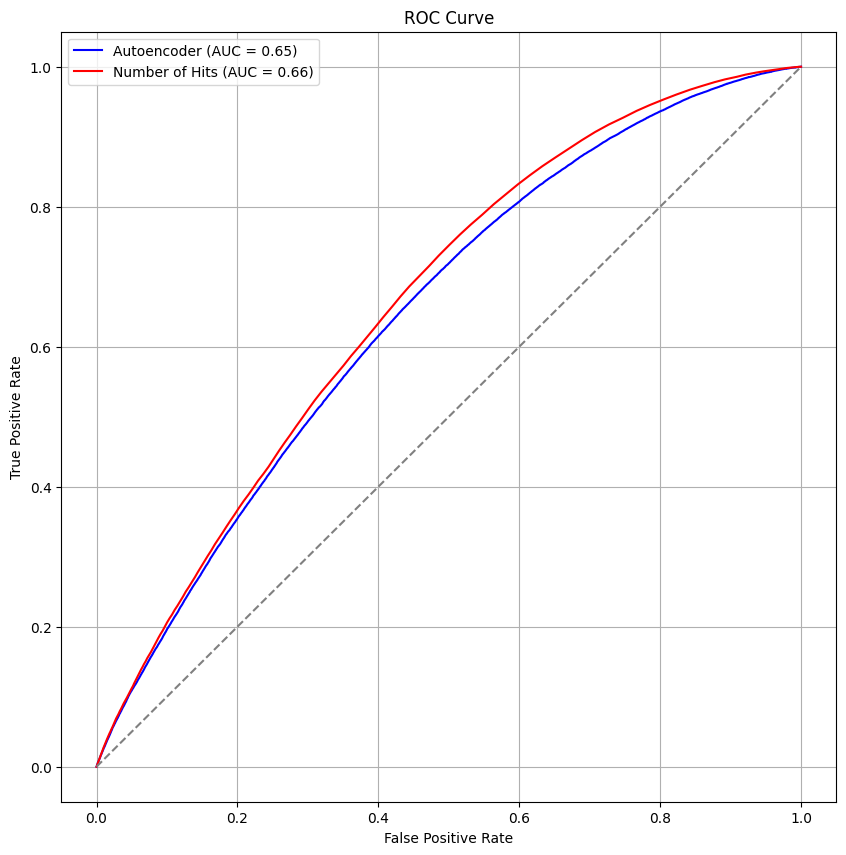

In [25]:
plt.figure(figsize=(10, 10))
plt.plot(fpr_autoencoder, tpr_autoencoder, label=f"Autoencoder (AUC = {roc_auc_autoencoder:.2f})", color="blue")
plt.plot(fpr_hits, tpr_hits, label=f"Number of Hits (AUC = {roc_auc_hits:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()